In [1]:
import sys
from pathlib import Path

raiz = Path.cwd()
if raiz.name == "notebooks":
    raiz = raiz.parent
sys.path.insert(0, str(raiz))

from lakehouse import Lakehouse

db = Lakehouse()
consultar = db.consultar
ejecutar = db.ejecutar

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

figuras = raiz / "figuras"
figuras.mkdir(exist_ok=True)

from analisis_comun import (FILTRO, CONTEOS, GRUPO_EDAD, GRUPO_GESTACION, ORDEN_EDAD,
                            ORDEN_GESTACION, ORDEN_EDUCACION, con_intervalos, barras)


In [2]:
# 1. Indicadores por año, tasa bruta y estandarizada por edad materna
conteos_anuales = f"""SELECT anio_nacimiento, {CONTEOS}
FROM __CATALOGO__.curated.nacimientos_peru
WHERE {FILTRO}
GROUP BY anio_nacimiento"""
ejecutar(f"""CREATE OR REPLACE TABLE __CATALOGO__.analytics.bajo_peso_anual
USING DELTA AS
{con_intervalos(conteos_anuales)}""")

# Estandarización directa: población estándar = distribución de edades de 2015-2025
estandarizada = consultar(f"""
WITH por_grupo AS (
  SELECT anio_nacimiento, {GRUPO_EDAD} AS grupo_edad,
         COUNT(*) AS n,
         AVG(CAST(es_bajo_peso_nacer AS INT)) AS tasa
  FROM __CATALOGO__.curated.nacimientos_peru
  WHERE {FILTRO} AND es_edad_madre_valida
  GROUP BY ALL
), estandar AS (
  SELECT grupo_edad, SUM(n) / SUM(SUM(n)) OVER () AS proporcion
  FROM por_grupo
  GROUP BY grupo_edad
)
SELECT anio_nacimiento,
       ROUND(100 * SUM(tasa * proporcion), 2) AS porcentaje_estandarizado_edad
FROM por_grupo JOIN estandar USING (grupo_edad)
GROUP BY anio_nacimiento
""")
anual = (consultar('SELECT * FROM __CATALOGO__.analytics.bajo_peso_anual')
         .merge(estandarizada, on='anio_nacimiento')
         .sort_values('anio_nacimiento'))
print(anual.to_string(index=False))
assert len(anual) == 11
assert (anual['bajo_peso'] <= anual['nacimientos']).all()
assert anual['porcentaje_bajo_peso'].between(0, 100).all()
total_analisis = int(anual['nacimientos'].sum())

 anio_nacimiento  nacimientos  bajo_peso  nacimientos_termino  bajo_peso_termino  porcentaje_bajo_peso  ic95_inferior  ic95_superior  porcentaje_bajo_peso_termino  porcentaje_estandarizado_edad
            2015       408930      22205               386220               9119                  5.43           5.36           5.50                          2.36                           5.43
            2016       450833      23851               425228               9665                  5.29           5.23           5.36                          2.27                           5.30
            2017       470716      24366               444376               9829                  5.18           5.11           5.24                          2.21                           5.18
            2018       484228      24693               456505               9731                  5.10           5.04           5.16                          2.13                           5.11
            2019       475658 

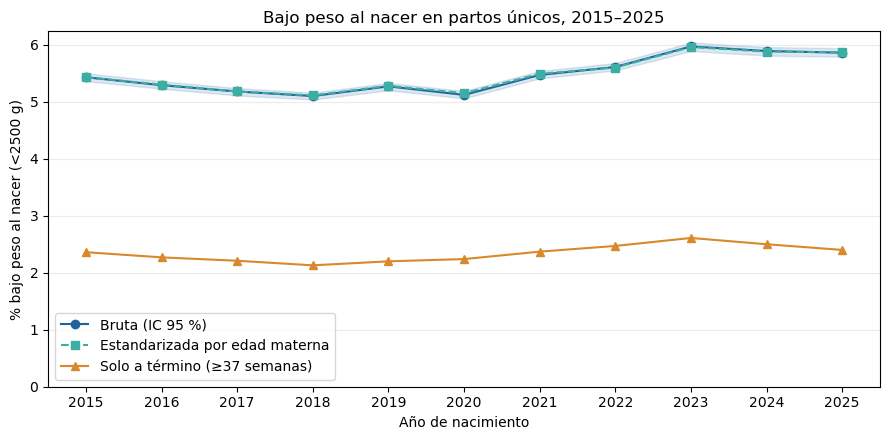

In [3]:
# 2. Graficar la tendencia anual
fig, ax = plt.subplots(figsize=(9, 4.5))
ax.fill_between(anual['anio_nacimiento'], anual['ic95_inferior'], anual['ic95_superior'],
                color='#20639B', alpha=0.15)
ax.plot(anual['anio_nacimiento'], anual['porcentaje_bajo_peso'], marker='o', color='#20639B',
        label='Bruta (IC 95 %)')
ax.plot(anual['anio_nacimiento'], anual['porcentaje_estandarizado_edad'], marker='s', linestyle='--',
        color='#3CAEA3', label='Estandarizada por edad materna')
ax.plot(anual['anio_nacimiento'], anual['porcentaje_bajo_peso_termino'], marker='^',
        color='#D8892B', label='Solo a término (≥37 semanas)')
ax.set(title='Bajo peso al nacer en partos únicos, 2015–2025', xlabel='Año de nacimiento',
       ylabel='% bajo peso al nacer (<2500 g)')
ax.set_xticks(anual['anio_nacimiento'])
ax.set_ylim(bottom=0)
ax.grid(axis='y', alpha=0.25)
ax.legend()
fig.tight_layout()
fig.savefig(figuras / 'bajo_peso_por_anio.png', dpi=180)
plt.show()

grupo_edad  nacimientos  bajo_peso  nacimientos_termino  bajo_peso_termino  porcentaje_bajo_peso  ic95_inferior  ic95_superior  porcentaje_bajo_peso_termino
     10-14        24989       2885                22219               1210                 11.55          11.15          11.95                          5.45
     15-19       615430      43961               577079              20313                  7.14           7.08           7.21                          3.52
     20-34      3258293     157627              3084094              64095                  4.84           4.81           4.86                          2.08
     35-39       670852      39303               621533              13657                  5.86           5.80           5.92                          2.20
     40-44       220995      16457               201185               5673                  7.45           7.34           7.56                          2.82
     45-60        14616       1611                12773   

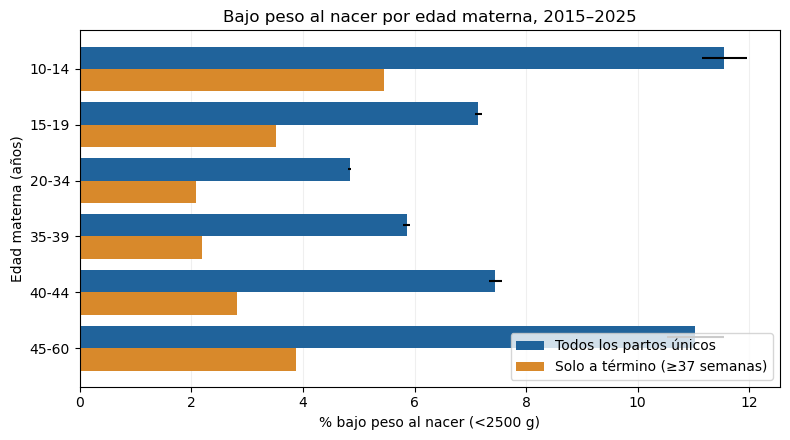

In [4]:
# 3. Indicadores por edad materna
conteos_edad = f"""SELECT {GRUPO_EDAD} AS grupo_edad, {CONTEOS}
FROM __CATALOGO__.curated.nacimientos_peru
WHERE {FILTRO}
GROUP BY ALL"""
ejecutar(f"""CREATE OR REPLACE TABLE __CATALOGO__.analytics.bajo_peso_edad_madre
USING DELTA AS
{con_intervalos(conteos_edad)}""")
edades = consultar('SELECT * FROM __CATALOGO__.analytics.bajo_peso_edad_madre')
edades = (edades.set_index('grupo_edad').reindex(ORDEN_EDAD + ['SIN DATO'])
          .dropna(subset=['nacimientos']).reset_index())
print(edades.to_string(index=False))
assert int(edades['nacimientos'].sum()) == total_analisis

fig, ax = plt.subplots(figsize=(8, 4.5))
barras(ax, edades.rename(columns={'grupo_edad': 'valor'}),
       'Bajo peso al nacer por edad materna, 2015–2025', orden=ORDEN_EDAD)
ax.set_ylabel('Edad materna (años)')
ax.legend(loc='lower right')
fig.tight_layout()
fig.savefig(figuras / 'bajo_peso_por_edad_madre.png', dpi=180)
plt.show()

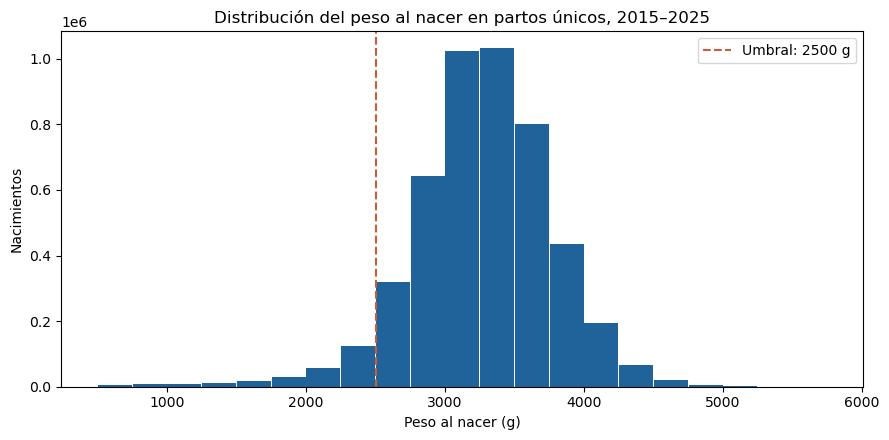

In [5]:
# 4. Revisar la distribución del peso
histograma = consultar(f"""
SELECT CAST(FLOOR(peso_nacido_g / 250) * 250 AS INT) AS peso_desde_g,
       COUNT(*) AS nacimientos
FROM __CATALOGO__.curated.nacimientos_peru
WHERE {FILTRO}
GROUP BY ALL
ORDER BY peso_desde_g
""")
fig, ax = plt.subplots(figsize=(9, 4.5))
ax.bar(histograma['peso_desde_g'] + 125, histograma['nacimientos'], width=245, color='#20639B')
ax.axvline(2500, color='#C85D38', linestyle='--', label='Umbral: 2500 g')
ax.set(title='Distribución del peso al nacer en partos únicos, 2015–2025',
       xlabel='Peso al nacer (g)', ylabel='Nacimientos')
ax.legend()
fig.tight_layout()
fig.savefig(figuras / 'distribucion_peso.png', dpi=180)
plt.show()

In [6]:
# 5. Comparar variables del nacimiento, de la madre y del lugar de residencia
conteos_variables = f"""SELECT dim.variable, dim.valor, {CONTEOS}
FROM __CATALOGO__.curated.nacimientos_peru
LATERAL VIEW EXPLODE(ARRAY(
  NAMED_STRUCT('variable', 'gestacion', 'valor', {GRUPO_GESTACION}),
  NAMED_STRUCT('variable', 'sexo', 'valor', COALESCE(sexo_nacido, 'SIN DATO')),
  NAMED_STRUCT('variable', 'educacion_madre', 'valor', COALESCE(nivel_instruccion_madre, 'SIN DATO')),
  NAMED_STRUCT('variable', 'estado_civil', 'valor', COALESCE(estado_civil, 'SIN DATO')),
  NAMED_STRUCT('variable', 'lugar_nacimiento', 'valor', COALESCE(lugar_nacido, 'SIN DATO')),
  NAMED_STRUCT('variable', 'financiador', 'valor', COALESCE(financiador_parto, 'SIN DATO')),
  NAMED_STRUCT('variable', 'pais_madre', 'valor', COALESCE(pais_madre_grupo, 'SIN DATO')),
  NAMED_STRUCT('variable', 'departamento', 'valor', COALESCE(departamento_residencia, 'SIN DATO')),
  NAMED_STRUCT('variable', 'mes', 'valor', CAST(mes_nacimiento AS STRING))
)) e AS dim
WHERE {FILTRO}
GROUP BY dim.variable, dim.valor"""
ejecutar(f"""CREATE OR REPLACE TABLE __CATALOGO__.analytics.bajo_peso_por_variable
USING DELTA AS
{con_intervalos(conteos_variables)}""")
agregado = consultar('SELECT * FROM __CATALOGO__.analytics.bajo_peso_por_variable')
for variable in agregado['variable'].unique():
    datos = agregado[agregado['variable'] == variable].sort_values('porcentaje_bajo_peso', ascending=False)
    assert int(datos['nacimientos'].sum()) == total_analisis
    print('\n', variable)
    print(datos.drop(columns='variable').to_string(index=False))


def variable(nombre, minimo=1000):
    datos = agregado[(agregado['variable'] == nombre) & (agregado['nacimientos'] >= minimo)]
    return datos[~datos['valor'].isin(['IGNORADO', 'SIN DATO'])]


 estado_civil
      valor  nacimientos  bajo_peso  nacimientos_termino  bajo_peso_termino  porcentaje_bajo_peso  ic95_inferior  ic95_superior  porcentaje_bajo_peso_termino
   SIN DATO       200926      17609               185392               8032                  8.76           8.64           8.89                          4.33
CONVIVIENTE        80004       5744                74395               2319                  7.18           7.00           7.36                          3.12
   SEPARADO           73          4                   71                  3                  5.48           2.15          13.26                          4.23
      VIUDO         2074        113                 1901                 38                  5.45           4.55           6.51                          2.00
 DIVORCIADO        18626       1001                16897                256                  5.37           5.06           5.71                          1.52
    SOLTERO      4067955     215425  

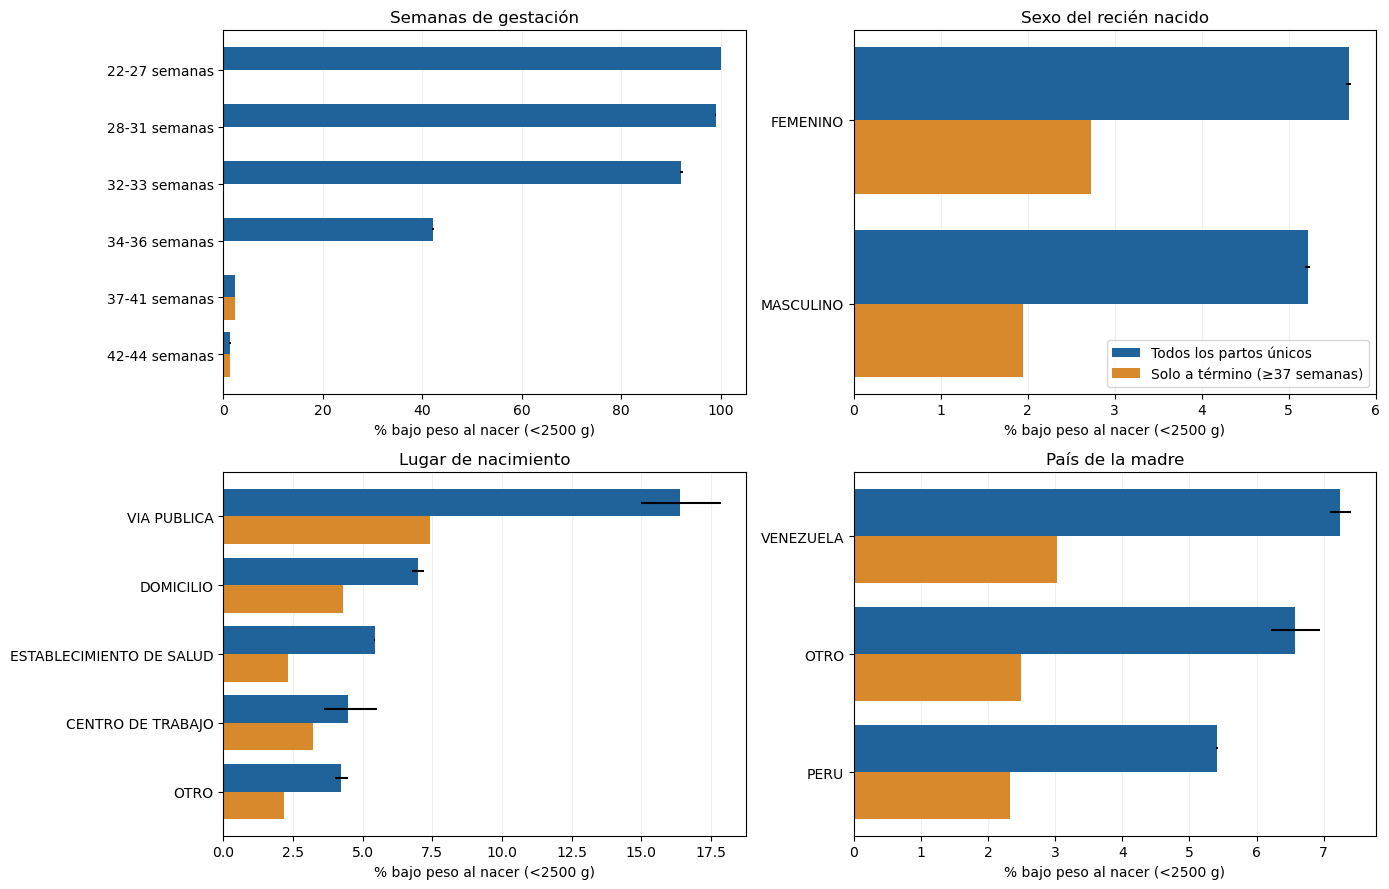

In [7]:
# 6. Graficar gestación, sexo, lugar de nacimiento y país de la madre
fig, ejes = plt.subplots(2, 2, figsize=(14, 9))
barras(ejes[0, 0], variable('gestacion'), 'Semanas de gestación', orden=ORDEN_GESTACION)
barras(ejes[0, 1], variable('sexo'), 'Sexo del recién nacido')
barras(ejes[1, 0], variable('lugar_nacimiento'), 'Lugar de nacimiento')
barras(ejes[1, 1], variable('pais_madre'), 'País de la madre')
ejes[0, 1].legend(loc='lower right')
fig.tight_layout()
fig.savefig(figuras / 'bajo_peso_otros_grupos.png', dpi=180)
plt.show()

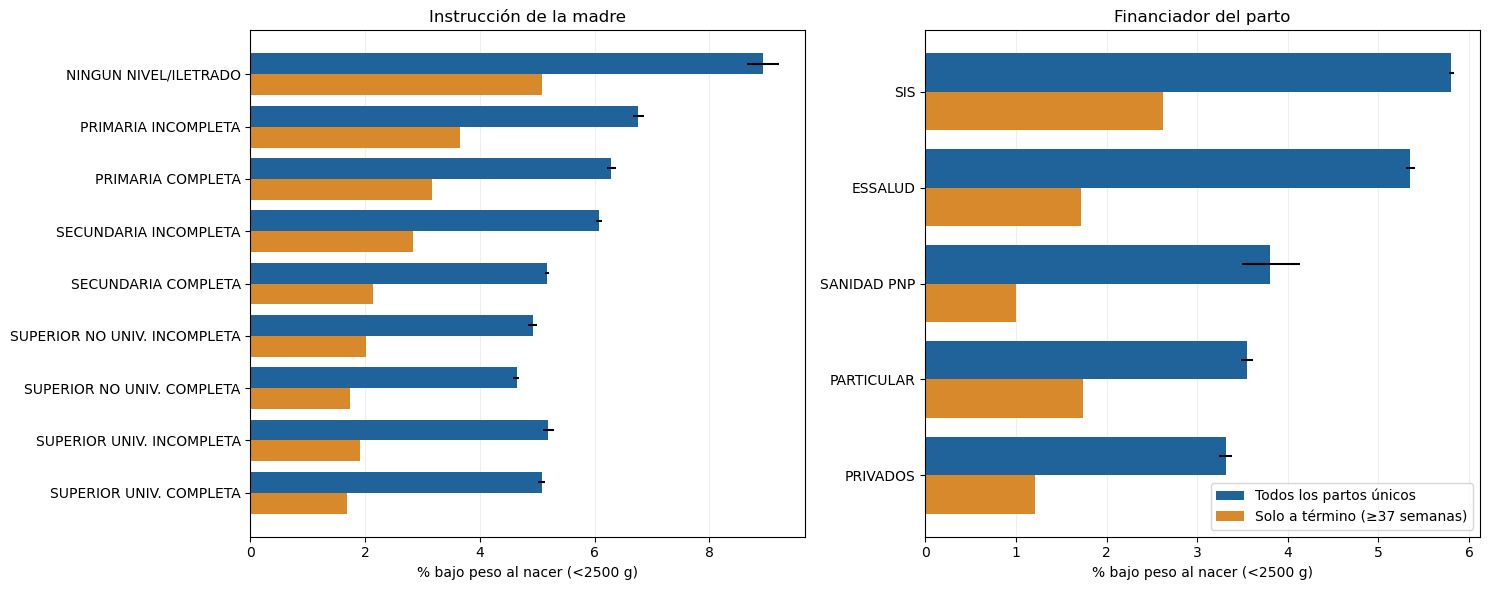

Por mes de nacimiento:
 mes_num  nacimientos  porcentaje_bajo_peso  ic95_inferior  ic95_superior
       1       405228                  5.50           5.43           5.57
       2       385737                  5.43           5.36           5.50
       3       427242                  5.46           5.40           5.53
       4       407457                  5.47           5.40           5.54
       5       412982                  5.39           5.32           5.46
       6       395623                  5.46           5.39           5.53
       7       404067                  5.45           5.38           5.52
       8       400080                  5.55           5.48           5.62
       9       409383                  5.17           5.10           5.24
      10       395383                  5.43           5.36           5.51
      11       376498                  5.43           5.36           5.51
      12       385554                  5.65           5.58           5.72


In [8]:
# 7. Revisar educación y financiación sin atribuir causalidad
fig, ejes = plt.subplots(1, 2, figsize=(15, 6))
barras(ejes[0], variable('educacion_madre'), 'Instrucción de la madre', orden=ORDEN_EDUCACION)
barras(ejes[1], variable('financiador', minimo=10000), 'Financiador del parto')
ejes[1].legend(loc='lower right')
fig.tight_layout()
fig.savefig(figuras / 'bajo_peso_contexto_materno.png', dpi=180)
plt.show()

meses = variable('mes').assign(mes_num=lambda d: d['valor'].astype(int)).sort_values('mes_num')
print('Por mes de nacimiento:')
print(meses[['mes_num', 'nacimientos', 'porcentaje_bajo_peso', 'ic95_inferior', 'ic95_superior']].to_string(index=False))

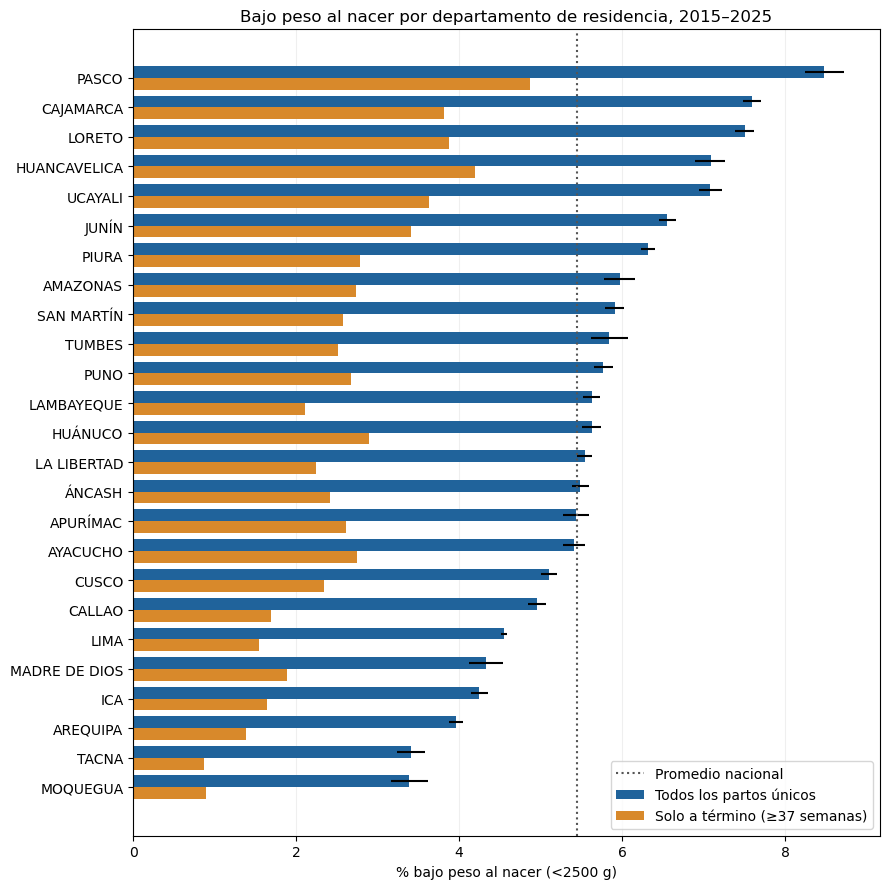

In [9]:
# 8. Comparar departamentos de residencia de la madre
departamentos = variable('departamento')
fig, ax = plt.subplots(figsize=(9, 9))
barras(ax, departamentos, 'Bajo peso al nacer por departamento de residencia, 2015–2025')
ax.axvline(100 * anual['bajo_peso'].sum() / total_analisis, color='#555555', linestyle=':',
           label='Promedio nacional')
ax.legend(loc='lower right')
fig.tight_layout()
fig.savefig(figuras / 'bajo_peso_departamento.png', dpi=180)
plt.show()

In [10]:
# 9. Cruzar edad materna con semanas de gestación
conteos_cruce = f"""SELECT {GRUPO_EDAD} AS grupo_edad, {GRUPO_GESTACION} AS grupo_gestacion, {CONTEOS}
FROM __CATALOGO__.curated.nacimientos_peru
WHERE {FILTRO}
GROUP BY ALL"""
ejecutar(f"""CREATE OR REPLACE TABLE __CATALOGO__.analytics.bajo_peso_edad_gestacion
USING DELTA AS
{con_intervalos(conteos_cruce)}""")
cruce = consultar('SELECT * FROM __CATALOGO__.analytics.bajo_peso_edad_gestacion')
assert int(cruce['nacimientos'].sum()) == total_analisis
tabla = cruce.pivot(index='grupo_edad', columns='grupo_gestacion', values='porcentaje_bajo_peso')
print('% de bajo peso por edad materna (filas) y semanas de gestación (columnas):')
print(tabla.reindex(index=ORDEN_EDAD, columns=ORDEN_GESTACION).to_string())

% de bajo peso por edad materna (filas) y semanas de gestación (columnas):
grupo_gestacion  22-27 semanas  28-31 semanas  32-33 semanas  34-36 semanas  37-41 semanas  42-44 semanas
grupo_edad                                                                                               
10-14                    100.0          97.41          92.86          49.09           5.44           6.67
15-19                    100.0          98.75          93.41          50.56           3.53           1.84
20-34                    100.0          98.95          92.22          41.18           2.08           1.09
35-39                    100.0          99.25          91.48          38.81           2.20           1.20
40-44                    100.0          99.39          89.80          41.70           2.82           2.24
45-60                    100.0          98.33          92.02          48.01           3.87           6.41


In [11]:
# 10. Resumen descriptivo
total_bajo = int(anual['bajo_peso'].sum())
termino = int(anual['nacimientos_termino'].sum())
bajo_termino = int(anual['bajo_peso_termino'].sum())
print(f'Partos únicos analizados: {total_analisis:,}.')
print(f'Bajo peso: {total_bajo:,} ({100 * total_bajo / total_analisis:.2f}%).')
print(f'Bajo peso a término: {bajo_termino:,} de {termino:,} ({100 * bajo_termino / termino:.2f}%).')
print('Se excluyen partos múltiples, pesos o semanas inválidos o inverosímiles y el año 2026 (en curso).')
print('Las comparaciones son descriptivas y no prueban causalidad.')

Partos únicos analizados: 4,805,234.
Bajo peso: 261,849 (5.45%).
Bajo peso a término: 105,447 de 4,518,939 (2.33%).
Se excluyen partos múltiples, pesos o semanas inválidos o inverosímiles y el año 2026 (en curso).
Las comparaciones son descriptivas y no prueban causalidad.
